<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Vacuum Neutrino Analysis 1 - Oscillation Probabilities
---
This notebook develops the full three-flavour vacuum oscillation framework using the
`tpeanuts` API. 
- Starts from the PMNS parametrisation and the exact transition-probability formula.
- it maps probabilities as functions of energy, baseline.
- Produces two-dimensional (E, L) maps for the electron-flavour survival and muon→electron appearance channels.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Transition-Probability-Matrix) | **Transition Probability Matrix** |
| [4](#4.-Probability-vs-Energy) | **Probability vs Energy** |
| [5](#5.-Probability-vs-Baseline) | **Probability vs Baseline** |
| [6](#6.-Two-Dimensional-Maps-PE-L) | **Two-Dimensional Maps P(E, L)** |
| [7](#7.-Summary) | **Summary** |


## 0. Theoretical Framework




### 0.1 PMNS Matrix Parametrisation

The Pontecorvo–Maki–Nakagawa–Sakata (PMNS) matrix [1,2] connects the neutrino mass eigenstates
$|\nu_i\rangle$ to the flavour eigenstates $|\nu_\alpha\rangle$:

$$
|\nu_\alpha\rangle = \sum_{i=1}^{3} U^*_{\alpha i}\, |\nu_i\rangle
$$

The standard parametrisation uses three mixing angles $\theta_{12}, \theta_{13}, \theta_{23}$
and a CP-violating Dirac phase $\delta_{\rm CP}$:

$$
U = \begin{pmatrix}
c_{12}c_{13} & s_{12}c_{13} & s_{13}e^{-i\delta} \\
-s_{12}c_{23}-c_{12}s_{23}s_{13}e^{i\delta} & c_{12}c_{23}-s_{12}s_{23}s_{13}e^{i\delta} & s_{23}c_{13} \\
s_{12}s_{23}-c_{12}c_{23}s_{13}e^{i\delta} & -c_{12}s_{23}-s_{12}c_{23}s_{13}e^{i\delta} & c_{23}c_{13}
\end{pmatrix}
$$

where $c_{ij} = \cos\theta_{ij}$, $s_{ij} = \sin\theta_{ij}$.




### 0.2 Vacuum Oscillation Probability Formula

The exact three-flavour vacuum oscillation probability for $\nu_\alpha \to \nu_\beta$ is [3]:

$$
P(\nu_\alpha \to \nu_\beta) = \delta_{\alpha\beta}
- 4 \sum_{i>j} \mathrm{Re}\!\left[U_{\alpha i}^* U_{\beta i} U_{\alpha j} U_{\beta j}^*\right]
  \sin^2\!\left(\frac{\Delta m^2_{ij} L}{4E}\right)
+ 2 \sum_{i>j} \mathrm{Im}\!\left[U_{\alpha i}^* U_{\beta i} U_{\alpha j} U_{\beta j}^*\right]
  \sin\!\left(\frac{\Delta m^2_{ij} L}{2E}\right)
$$

In natural units with the practical conversion $\Delta m^2_{ij} [\text{eV}^2] \cdot L [\text{km}]
/ E [\text{GeV}] \to$ phase $\phi_{ij} = 1.2669\, \Delta m^2_{ij} L / E_{\rm GeV}$.

The last (imaginary) term changes sign under $\nu \to \bar\nu$ (CP conjugation), generating
the CP asymmetry. It is also antisymmetric under $\alpha \leftrightarrow \beta$, so in general
$P(\nu_\alpha \to \nu_\beta) \neq P(\nu_\beta \to \nu_\alpha)$ whenever $\delta_{\rm CP} \neq 0,\pi$
(a genuine T-violation, distinct from the CP asymmetry above). Both row sums and column sums of
the $3\times 3$ probability matrix equal 1 (unitarity).

`tpeanuts` returns $P_{\beta\alpha}$ (P[…, β, α] in index order) — final-state index first.




### 0.3 Oscillation Lengths

From the phase appearing in §0.2, $\phi_{ij} = \Delta m^2_{ij} L / (4E)$ (natural units,
$\hbar=c=1$). Since $\sin^2$ has period $\pi$ in its argument, the oscillation length
$L_{\rm osc}$ — the baseline over which the phase advances by one full period — is defined by
setting $\phi = \pi$:

$$
\frac{\Delta m^2_{ij}\, L_{\rm osc}}{4E} = \pi
\quad\Longrightarrow\quad
L_{\rm osc} = \frac{4\pi E}{\Delta m^2_{ij}}
$$

Restoring $\hbar$, $c$ and converting to the practical units used throughout this notebook
($E$ in MeV, $\Delta m^2$ in eV², $L$ in km) gives the numerical factor [4]:

$$
L_{\rm osc}[\text{km}] = 2.478\times 10^{-3}\,
\frac{E[\text{MeV}]}{|\Delta m^2[\text{eV}^2]|}
$$

| Splitting | $\Delta m^2$ (eV²) | $L_{\rm osc}$ at 1 GeV |
|---|---|---|
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ | ≈ 33 500 km |
| $\Delta m^2_{31}$ | $2.511\times10^{-3}$ | ≈ 987 km |
| $\Delta m^2_{32}$ | $\approx 2.437\times10^{-3}$ | ≈ 1 017 km |

The first oscillation maximum (survival minimum) occurs at $L = L_{\rm osc}/2$.




### 0.4 tpeanuts Vacuum API Overview

| Function | Signature | Returns |
|---|---|---|
| `vacuum_probability_transition` | `(oscillation, E_MeV, L_km)` | `Tensor(..., 3, 3)` — P[β, α] |
| `vacuum_probability_state` | `(nustate, oscillation, E_MeV, L_km)` | `Tensor(..., 3)` |
| `vacuum_flux_state` | `(nustate, oscillation, E_MeV, L_km, flux, spectrum)` | `Tensor(..., 3)` |
| `vacuum_evolutor` | `(oscillation, E_MeV, L_km)` | `Tensor(..., 3, 3)` — complex S |
| `vacuum_evolved_state` | `(nustate, oscillation, E_MeV, L_km)` | `Tensor(..., 3)` — complex amplitudes |

All functions accept broadcast-compatible batch dimensions (e.g. shape `(NE, 1)` × `(1, NL)` → `(NE, NL, 3, 3)`).






**References**

- [1] B. Pontecorvo, Zh. Eksp. Teor. Fiz. **33**, 549 (1957) [Sov. Phys. JETP **6**, 429 (1957)]; ibid. **53**, 1717 (1967) [Sov. Phys. JETP **26**, 984 (1968)].
- [2] Z. Maki, M. Nakagawa and S. Sakata, *Prog. Theor. Phys.* **28**, 870 (1962).
- [3] Giunti, C., & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*. Oxford University Press.
- [4] R. L. Workman, et al. (Particle Data Group), *Prog. Theor. Exp. Phys.* **2022**, 083C01.
- [5] I. Esteban, et al. (NuFIT 5.2), *JHEP* **09**, 178 (2020); NuFIT 5.2.


## 1. Libraries

All physics, plotting, and utility imports.




In [1]:
from __future__ import annotations

import dataclasses
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition, vacuum_probability_state
from tpeanuts.medium.vacuum.flux import vacuum_flux_state
from tpeanuts.medium.vacuum.evolutor import vacuum_evolutor, vacuum_evolved_state
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_LABELS, FLAVOUR_COLORS, to_numpy, save_and_show,
)
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration




### 2.1 Paths




In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "vacuum")
SHOW_PLOTS = config.show_plots

print("Output directory:", OUTPUT_DIR)

Output directory: v:\output\analysis\vacuum


### 2.2 Configuration

Physical parameters from NuFIT 5.2 [5] Normal Ordering (with SK atmospheric data):

| Parameter | Value |
|---|---|
| $\theta_{12}$ | 33.41° |
| $\theta_{13}$ | 8.58° |
| $\theta_{23}$ | 49.0° |
| $\delta_{\rm CP}$ | 197° |
| $\Delta m^2_{21}$ | $7.41\times10^{-5}$ eV² |
| $\Delta m^2_{3\ell}$ (NO) | $+2.511\times10^{-3}$ eV² |

Oscillation parameters for normal ordering (NO) and antineutrinos ($\bar{\nu}$) are constructed below.
Oscillation lengths for the three splittings at a reference energy of 1 GeV are printed as a
cross-check against the analytic values in §0.3. A default baseline `L0_DEFAULT` is also defined
here for reuse in the fixed-$L$ studies of §3 and §4.




In [3]:
# NuFIT 5.2 Normal Ordering
osc = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
osc_bar = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=True, context=ctx)

DM21  = float(osc.mass_spectrum.DeltamSq21)   # eV²
DM3L  = float(osc.mass_spectrum.DeltamSq3l)   # eV²
DM32  = DM3L - DM21              # eV²

L0_DEFAULT = 500.0  # km -- reference baseline for the fixed-L studies in SS3/SS4

E_REF_MeV = 1000.0  # 1 GeV reference energy
L_osc_21  = 2.478e-3 * E_REF_MeV / abs(DM21)
L_osc_31  = 2.478e-3 * E_REF_MeV / abs(DM3L)
L_osc_32  = 2.478e-3 * E_REF_MeV / abs(DM32)

print("=== NuFIT 5.2 NO parameters ===")
print(f"  theta12 = {math.degrees(float(osc.pmns.params.theta12)):.3f} deg")
print(f"  theta13 = {math.degrees(float(osc.pmns.params.theta13)):.3f} deg")
print(f"  theta23 = {math.degrees(float(osc.pmns.params.theta23)):.3f} deg")
print(f"  delta   = {math.degrees(float(osc.pmns.params.delta)):.2f} deg")
print(f"  Dm21    = {DM21:.4e} eV^2")
print(f"  Dm3l    = {DM3L:.4e} eV^2")
print()
print("=== Oscillation lengths at E=1 GeV ===")
print(f"  L_osc(Dm21) = {L_osc_21:,.0f} km")
print(f"  L_osc(Dm31) = {L_osc_31:,.0f} km")
print(f"  L_osc(Dm32) = {L_osc_32:,.0f} km")

=== NuFIT 5.2 NO parameters ===
  theta12 = 33.410 deg
  theta13 = 8.580 deg
  theta23 = 49.000 deg
  delta   = 197.00 deg
  Dm21    = 7.4100e-05 eV^2
  Dm3l    = 2.5110e-03 eV^2

=== Oscillation lengths at E=1 GeV ===
  L_osc(Dm21) = 33,441 km
  L_osc(Dm31) = 987 km
  L_osc(Dm32) = 1,017 km


## 3. Transition Probability Matrix






### 3.1 Probability Matrix at Fixed (E, L)

`vacuum_probability_transition` returns a 3×3 tensor $P[\beta, \alpha]$ (rows = final flavour, cols = initial flavour)
at a single (E, L) point. The matrix is displayed both as a styled pandas DataFrame and as an
annotated heatmap.

**Expected results:** At $E=1\,\mathrm{GeV}$, $L=500\,\mathrm{km}$ (`L0_DEFAULT`, close to the
first $\Delta m^2_{31}$ survival minimum $L_{\rm osc}(\Delta m^2_{31})/2\approx493\,\mathrm{km}$):
- $\nu_e$ survival $P_{ee}$ stays high, $\approx0.91$, bounded from below by the small
  $\theta_{13}$ mixing.
- The $2$–$3$ sector is almost maximally mixed: $P_{\mu\mu}$ and $P_{\tau\tau}$ both drop to
  $\approx0.01$–$0.02$, with $\nu_\mu \leftrightarrow \nu_\tau$ largely interchanging instead.






Transition probability matrix P[beta, alpha] at E=1 GeV, L=500 km:


,$\nu_e$,$\nu_\mu$,$\nu_\tau$
Final \ Initial,,,
$\nu_e$,0.9112,0.0538,0.0350
$\nu_\mu$,0.0465,0.0134,0.9401
$\nu_\tau$,0.0423,0.9328,0.0249


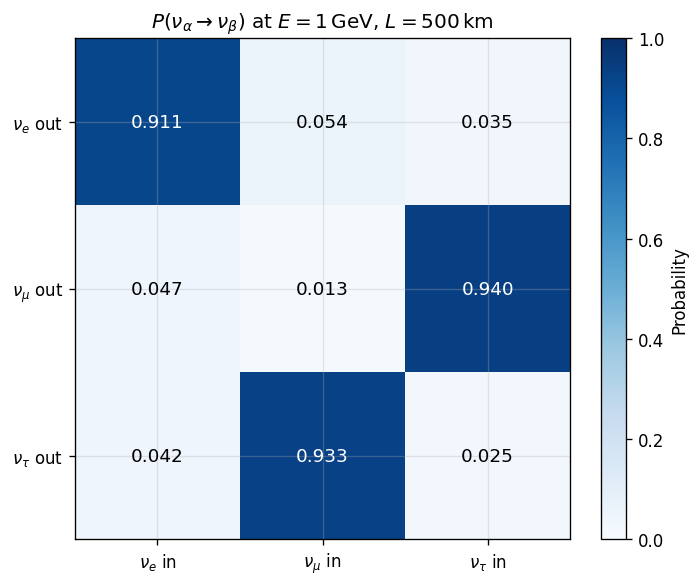

v:\output\analysis\vacuum\vf1_fig31_1_prob_matrix_heatmap.png


In [4]:
E0 = torch.tensor(1000.0, dtype=ctx.dtype, device=ctx.device)   # 1 GeV in MeV
L0 = torch.tensor(L0_DEFAULT, dtype=ctx.dtype, device=ctx.device)   # km

P_mat = vacuum_probability_transition(osc, E0, L0)  # (3, 3)
P_np  = to_numpy(P_mat)

flavours = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
df = pd.DataFrame(P_np, index=flavours, columns=flavours)
df.index.name   = "Final \ Initial"
print(f"Transition probability matrix P[beta, alpha] at E=1 GeV, L={L0_DEFAULT:.0f} km:")
display(df.style.format("{:.4f}").background_gradient(cmap="Blues", vmin=0.0, vmax=1.0))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(P_np, vmin=0.0, vmax=1.0, cmap="Blues", aspect="auto")
fig.colorbar(im, ax=ax, label="Probability")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([r"$\nu_e$ in", r"$\nu_\mu$ in", r"$\nu_\tau$ in"])
ax.set_yticklabels([r"$\nu_e$ out", r"$\nu_\mu$ out", r"$\nu_\tau$ out"])
ax.set_title(rf"$P(\nu_\alpha \to \nu_\beta)$ at $E=1\,\mathrm{{GeV}}$, $L={L0_DEFAULT:.0f}\,\mathrm{{km}}$")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{P_np[i, j]:.3f}", ha="center", va="center", fontsize=11,
                color="white" if P_np[i, j] > 0.5 else "black")
fig.tight_layout()
save_and_show("vf1_fig31_1_prob_matrix_heatmap.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Unitarity Check

Unitarity requires every row sum and every column sum to equal 1 exactly. Here we verify this
on 2000 random (E, L) points spanning 1 MeV–10 GeV and 1–10 000 km.

**Expected results:** 
- Both row and column sum deviations should be at the level of floating-point
machine precision (~1e-14 for float64), confirming that `vacuum_probability_transition` is internally
consistent.






Max row-sum deviation : 7.772e-16
Max col-sum deviation : 6.661e-16
Unitarity check: PASS


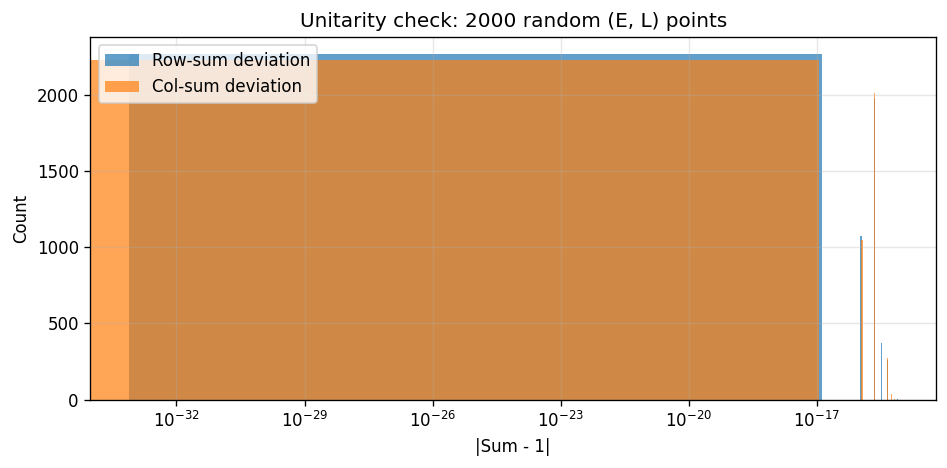

v:\output\analysis\vacuum\vf1_fig32_1_unitarity_check.png


In [5]:
rng = np.random.default_rng(42)
N = 2000
E_rand = torch.tensor(rng.uniform(1.0, 1e4, N),    dtype=ctx.dtype, device=ctx.device)
L_rand = torch.tensor(rng.uniform(1.0, 1e4, N),    dtype=ctx.dtype, device=ctx.device)

P_rand = vacuum_probability_transition(osc, E_rand, L_rand)   # (N, 3, 3)

row_sums = to_numpy(P_rand.sum(dim=-2))  # sum over beta (final) for each alpha → shape (N, 3)
col_sums = to_numpy(P_rand.sum(dim=-1))  # sum over alpha (initial) for each beta → shape (N, 3)
row_dev  = np.abs(row_sums - 1.0)
col_dev  = np.abs(col_sums - 1.0)

print(f"Max row-sum deviation : {row_dev.max():.3e}")
print(f"Max col-sum deviation : {col_dev.max():.3e}")

status = "PASS" if row_dev.max() < 1e-10 and col_dev.max() < 1e-10 else "FAIL"
print(f"Unitarity check: {status}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(row_dev.ravel(), bins=60, alpha=0.7, label="Row-sum deviation", color="C0")
ax.hist(col_dev.ravel(), bins=60, alpha=0.7, label="Col-sum deviation", color="C1")
ax.set_xlabel("|Sum - 1|")
ax.set_ylabel("Count")
ax.set_xscale("log")
ax.set_title("Unitarity check: 2000 random (E, L) points")
ax.legend()
fig.tight_layout()
save_and_show("vf1_fig32_1_unitarity_check.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 ν vs ν̄ Probability Matrices

Under CP conjugation ($\delta_{\rm CP} \to -\delta_{\rm CP}$) the oscillation probabilities
for neutrinos and antineutrinos differ in the interference (imaginary) term. The diagonal survival
channels are not affected at leading order; the off-diagonal appearance channels show the most
sensitivity.

**Expected results:** 
- The diagonal elements (survival) will be nearly identical.
- The largest differences will appear in the off-diagonal channels — particularly in $P(\nu_\mu\to\nu_e)$ vs $P(\bar\nu_\mu\to\bar\nu_e)$.






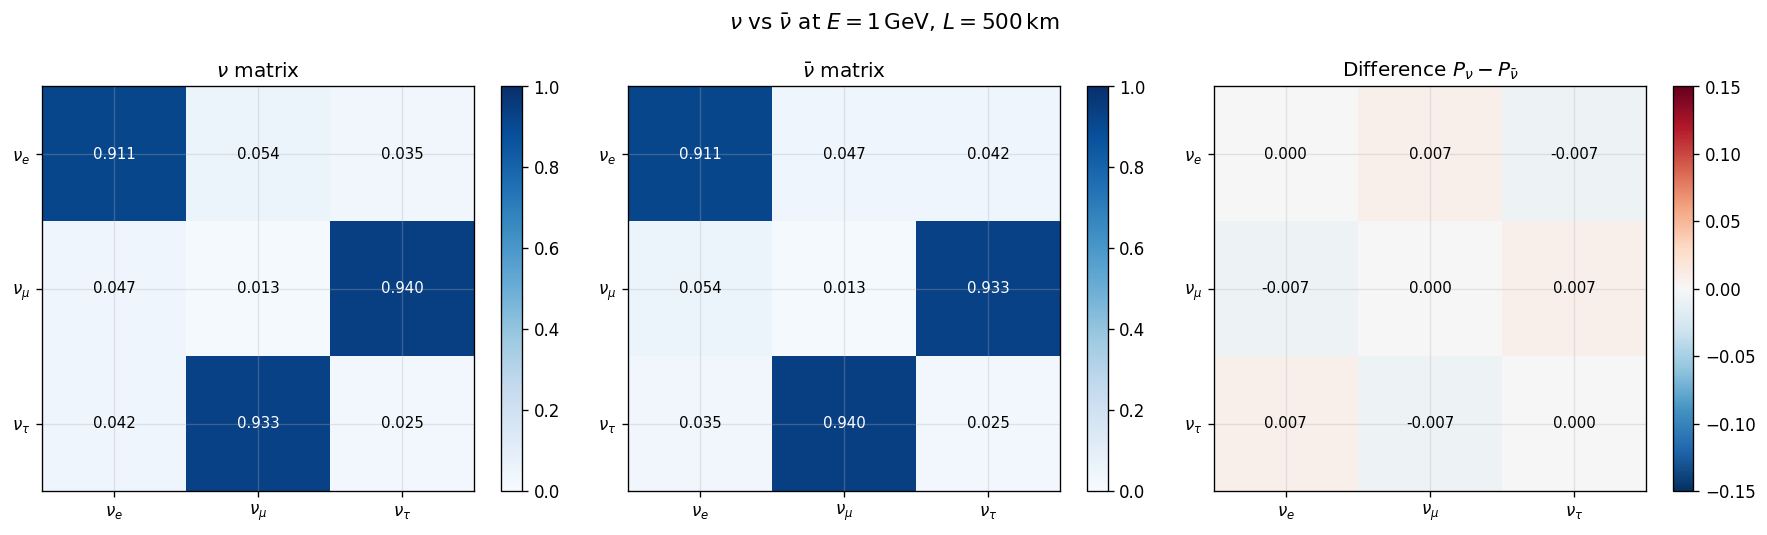

v:\output\analysis\vacuum\vf1_fig33_1_nu_nubar_matrices.png


In [6]:
P_nu  = to_numpy(vacuum_probability_transition(osc,     E0, L0))
P_bar = to_numpy(vacuum_probability_transition(osc_bar, E0, L0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, data, title in zip(axes,
                            [P_nu, P_bar, P_nu - P_bar],
                            [r"$\nu$ matrix", r"$\bar\nu$ matrix", r"Difference $P_\nu - P_{\bar\nu}$"]):
    vmin = -0.15 if "Diff" in title else 0.0
    vmax = 0.15  if "Diff" in title else 1.0
    cmap = "RdBu_r" if "Diff" in title else "Blues"
    im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels([r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"])
    ax.set_yticklabels([r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"])
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(data[i,j]) > 0.5 else "black")
fig.suptitle(rf"$\nu$ vs $\bar\nu$ at $E=1\,\mathrm{{GeV}}$, $L={L0_DEFAULT:.0f}\,\mathrm{{km}}$", fontsize=13)
fig.tight_layout()
save_and_show("vf1_fig33_1_nu_nubar_matrices.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Probability vs Energy






### 4.1 Survival Channels vs Energy

Survival probabilities $P_{ee}$, $P_{\mu\mu}$, $P_{\tau\tau}$ as functions of neutrino energy at
fixed $L=500\,\mathrm{km}$ (`L_fixed = L0_DEFAULT`). The oscillatory pattern is driven primarily
by the atmospheric splitting $\Delta m^2_{31}$; since the phase scales as $1/E$, the oscillations
are faster at lower energy.

**Expected results:** 
- Near the two-flavour estimate $E\approx1013\,\mathrm{MeV}$ (solving $L_{\rm fixed}=L_{\rm osc}(\Delta m^2_{31})/2$ for $E$), $P_{ee}$ reaches a local minimum of $\approx0.91$, bounded from below by the small $\theta_{13}$ mixing.
- $P_{\mu\mu}$ and $P_{\tau\tau}$ dip much deeper at the same energy, down to $\approx0.01$–$0.02$, since $\theta_{23}$ is close to maximal.
- At lower energies (below a few hundred MeV) additional minima appear as the solar splitting $\Delta m^2_{21}$ phase becomes non-negligible.






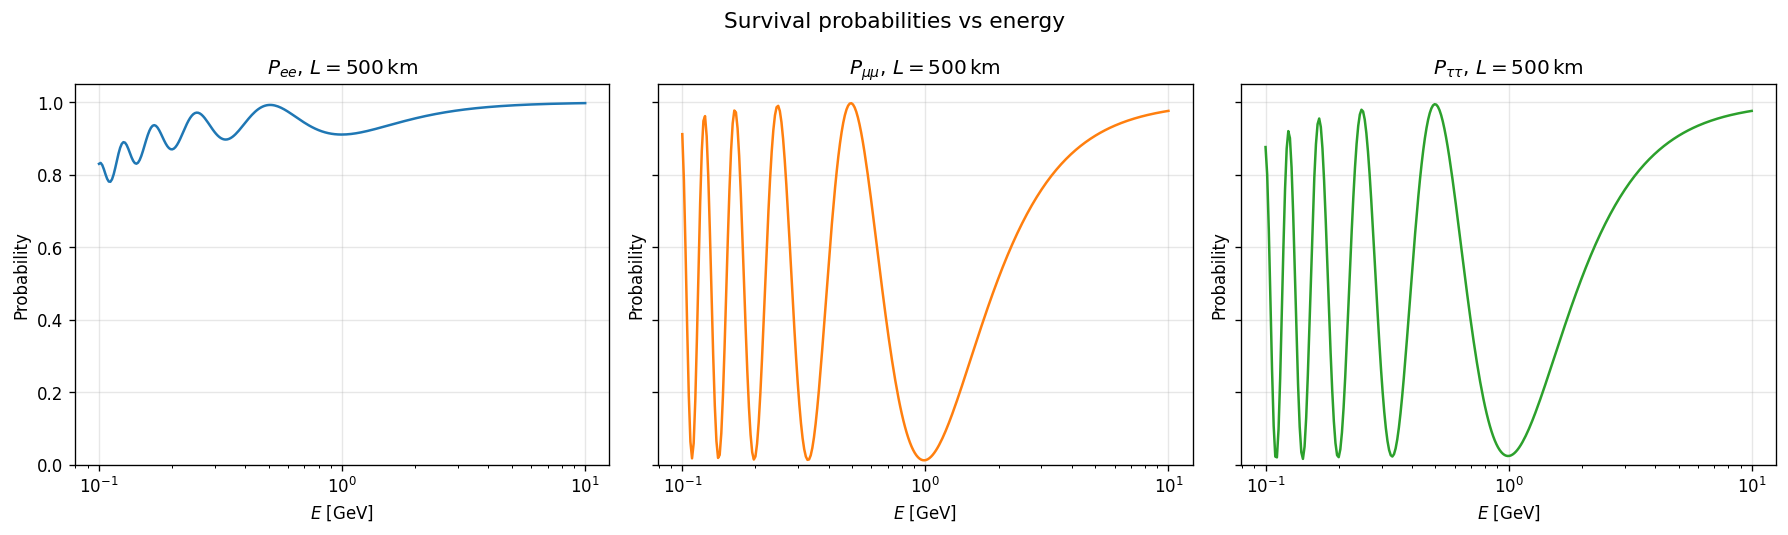

v:\output\analysis\vacuum\vf1_fig41_1_survival_vs_E.png


In [7]:
E_scan_MeV = torch.logspace(math.log10(100.0), math.log10(1e4), 300,
                             dtype=ctx.dtype, device=ctx.device)
L_fixed    = torch.tensor(L0_DEFAULT, dtype=ctx.dtype, device=ctx.device)

P_vs_E = vacuum_probability_transition(osc, E_scan_MeV, L_fixed)   # (300, 3, 3)
E_np   = to_numpy(E_scan_MeV) * 1e-3                     # GeV for x-axis

# Diagonal: P[beta=alpha]
labels_surv = [r"$P_{ee}$", r"$P_{\mu\mu}$", r"$P_{\tau\tau}$"]
colors_surv = ["C0", "C1", "C2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for i, (label, color) in enumerate(zip(labels_surv, colors_surv)):
    axes[i].semilogx(E_np, to_numpy(P_vs_E[:, i, i]), color=color)
    axes[i].set_xlabel(r"$E$ [GeV]")
    axes[i].set_ylabel("Probability")
    axes[i].set_title(label + rf", $L={L0_DEFAULT:.0f}\,\mathrm{{km}}$")
    axes[i].set_ylim(0, 1.05)
fig.suptitle("Survival probabilities vs energy", fontsize=13)
fig.tight_layout()
save_and_show("vf1_fig41_1_survival_vs_E.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.2 Appearance Channels vs Energy

Off-diagonal appearance probabilities $P_{e\mu}$, $P_{e\tau}$, $P_{\mu\tau}$ at
$L=500\,\mathrm{km}$. These channels vanish only in the absence of mixing and are sensitive to
the CP phase.

**Expected results:** 
- Near the atmospheric oscillation maximum ($E\approx1\,\mathrm{GeV}$), $P_{e\mu}$ and $P_{e\tau}$ peak at order $\sin^2(2\theta_{13})\sin^2(\theta_{23})\approx0.05$, suppressed by the small $\theta_{13}$ mixing.
- Because $\delta_{\rm CP}\neq0$, this is a genuine T-violation and $P(\nu_e\to\nu_\mu) \neq P(\nu_\mu\to\nu_e)$ in general (cf. §3.3).
- $P_{\mu\tau}$ is governed instead by the near-maximal $2$–$3$ mixing and can approach unity, so it is shown on
its own vertical scale.






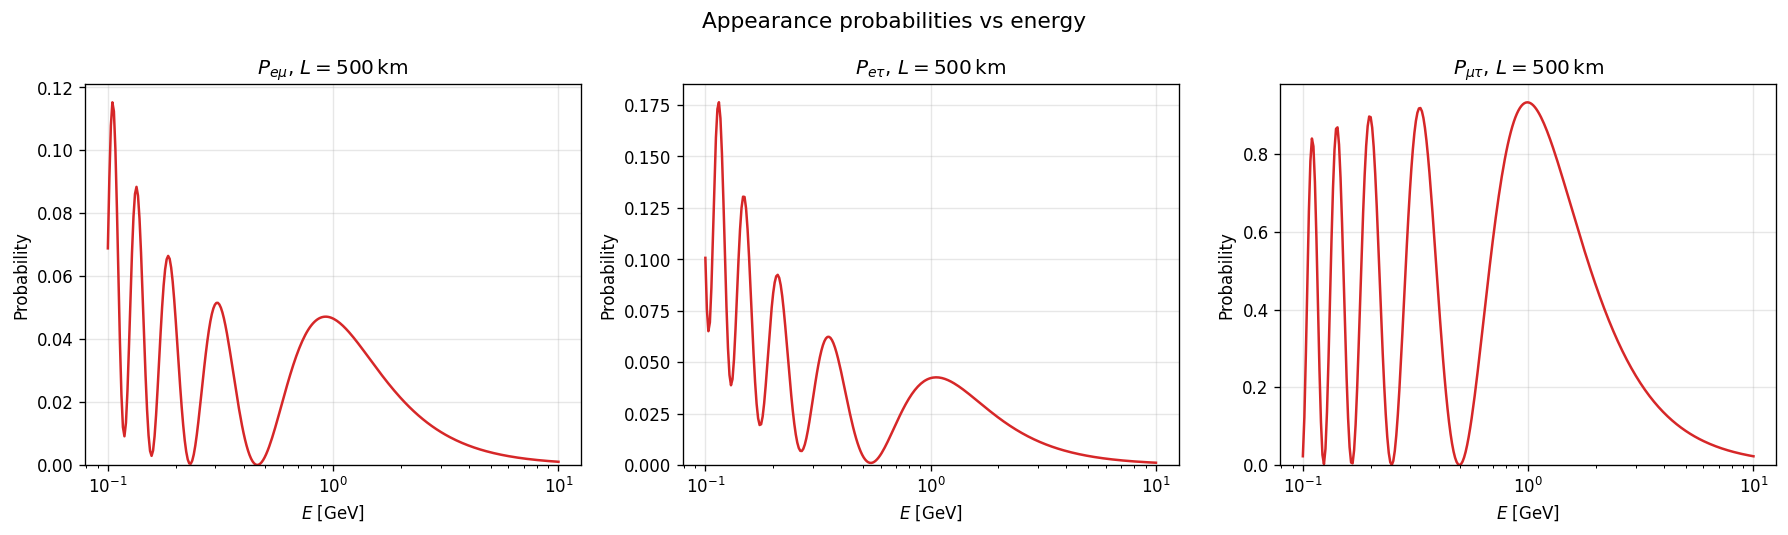

v:\output\analysis\vacuum\vf1_fig42_1_appearance_vs_E.png


In [8]:
labels_app = [r"$P_{e\mu}$", r"$P_{e\tau}$", r"$P_{\mu\tau}$"]
# (alpha, beta) index pairs for appearance: (e→mu, e→tau, mu→tau)
pairs      = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (alpha, beta), label in zip(axes, pairs, labels_app):
    ax.semilogx(E_np, to_numpy(P_vs_E[:, beta, alpha]), color="C3")
    ax.set_xlabel(r"$E$ [GeV]")
    ax.set_ylabel("Probability")
    ax.set_title(label + rf", $L={L0_DEFAULT:.0f}\,\mathrm{{km}}$")
    ax.set_ylim(bottom=0)
fig.suptitle("Appearance probabilities vs energy", fontsize=13)
fig.tight_layout()
save_and_show("vf1_fig42_1_appearance_vs_E.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Probability vs Baseline






### 5.1 All Channels vs Baseline at E=1 GeV

All nine channels of the probability matrix as a function of baseline $L$ for $E=1\,\mathrm{GeV}$.
Survival channels are shown in the left panel; appearance channels in the right panel. Both
panels share the same $L$ axis on a log scale to span from atmospheric ($100\,\mathrm{km}$) to
solar ($15\,000\,\mathrm{km}$) baselines.

**Expected results:** 
- The survival probabilities oscillate with period $\sim L_{\rm osc}(\Delta m^2_{31})\sim1000\,\mathrm{km}$ near the atmospheric oscillation scale.
- At very long baselines the averaging due to the solar splitting $\Delta m^2_{21}$ becomes apparent.






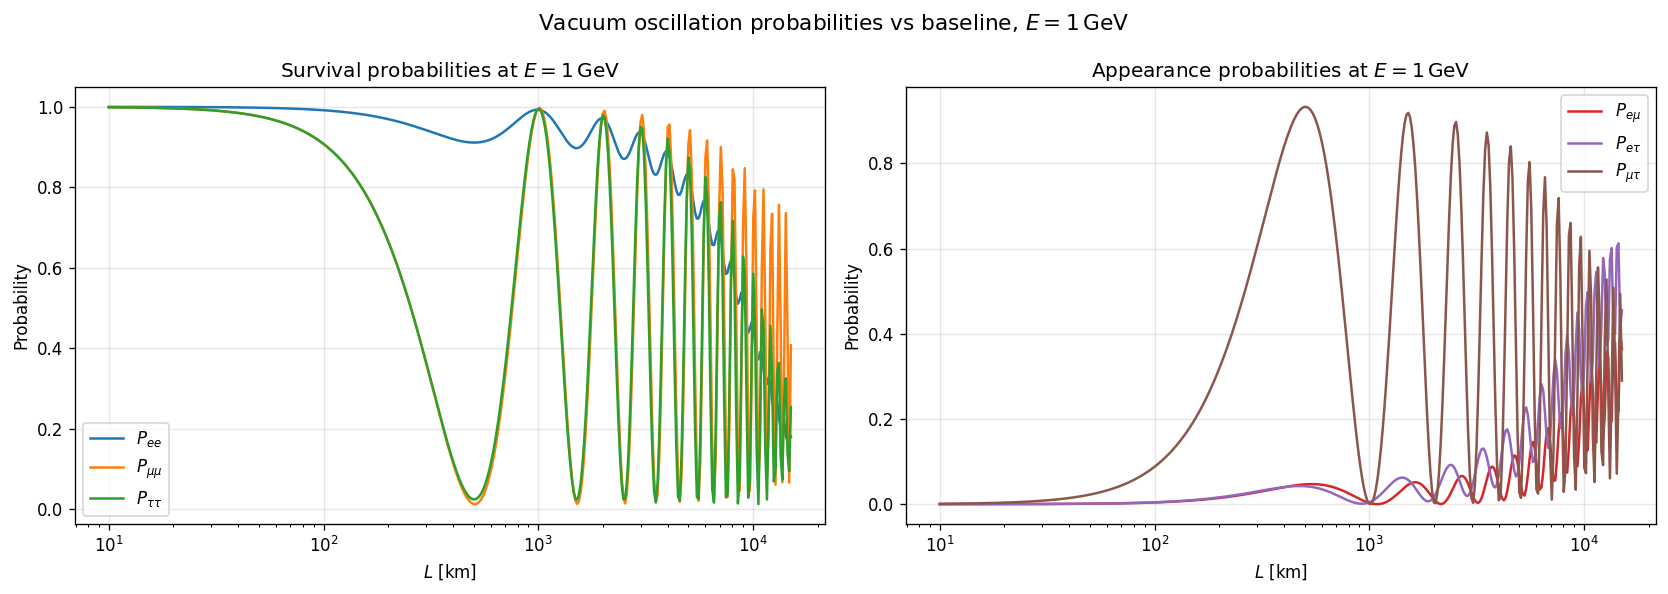

v:\output\analysis\vacuum\vf1_fig51_1_prob_vs_L.png


In [9]:
E_fixed    = torch.tensor(1000.0, dtype=ctx.dtype, device=ctx.device)
L_scan     = torch.logspace(math.log10(10.0), math.log10(15000.0), 400,
                             dtype=ctx.dtype, device=ctx.device)

P_vs_L = vacuum_probability_transition(osc, E_fixed, L_scan)   # (400, 3, 3)
L_np   = to_numpy(L_scan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Survival (diagonal)
for i, (label, color) in enumerate(zip(labels_surv, colors_surv)):
    axes[0].semilogx(L_np, to_numpy(P_vs_L[:, i, i]), label=label, color=color)
axes[0].set_xlabel(r"$L$ [km]")
axes[0].set_ylabel("Probability")
axes[0].set_title(r"Survival probabilities at $E=1\,\mathrm{GeV}$")
axes[0].legend()

# Appearance (off-diagonal)
app_triples = [(0, 1, r"$P_{e\mu}$", "C3"), (0, 2, r"$P_{e\tau}$", "C4"), (1, 2, r"$P_{\mu\tau}$", "C5")]
for alpha, beta, label, color in app_triples:
    axes[1].semilogx(L_np, to_numpy(P_vs_L[:, beta, alpha]), label=label, color=color)
axes[1].set_xlabel(r"$L$ [km]")
axes[1].set_ylabel("Probability")
axes[1].set_title(r"Appearance probabilities at $E=1\,\mathrm{GeV}$")
axes[1].legend()

fig.suptitle(r"Vacuum oscillation probabilities vs baseline, $E=1\,\mathrm{GeV}$", fontsize=13)
fig.tight_layout()
save_and_show("vf1_fig51_1_prob_vs_L.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Oscillation Length Extraction

The $\nu_e$ survival probability $P_{ee}$ vs $L$ in linear scale for $L\in[100,3000]\,\mathrm{km}$
at $E=1\,\mathrm{GeV}$. The first minimum, searched for within the first complete oscillation
($L\in[0,1000]\,\mathrm{km}$) to avoid a deeper, later minimum caused by solar-term
interference, is marked and compared with the analytic prediction
$L_{\rm osc}(\Delta m^2_{31})/2$.

**Expected results:** 
- The first minimum of $P_{ee}$ should occur at $L\approx L_{\rm osc}(\Delta m^2_{31})/2\approx493\,\mathrm{km}$ at $E=1\,\mathrm{GeV}$.
- The difference between the numerical minimum and the analytic formula should be small, confirming the effective two-flavour picture for the atmospheric sector.






Analytic L_osc(Dm31)/2  = 493.4 km
Numerical first minimum = 501.0 km
Difference              = 7.6 km


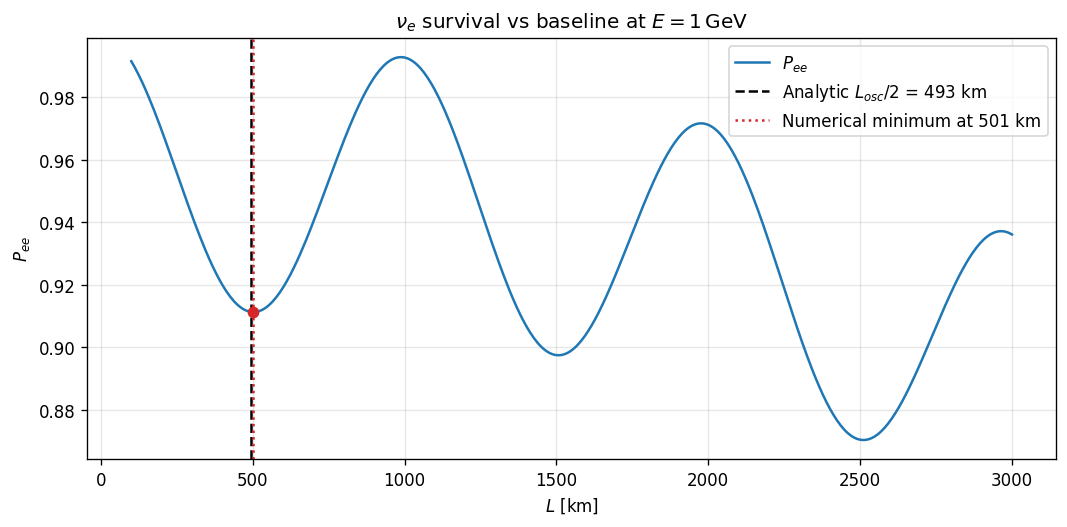

v:\output\analysis\vacuum\vf1_fig52_1_oscillation_length.png


In [10]:
L_lin = torch.linspace(100.0, 3000.0, 500, dtype=ctx.dtype, device=ctx.device)
P_ee_lin = to_numpy(vacuum_probability_transition(osc, E_fixed, L_lin)[:, 0, 0])
L_lin_np  = to_numpy(L_lin)

# Analytic oscillation half-length for Dm31
L_half_analytic = L_osc_31 / 2.0

# Restrict the search to the first complete oscillation (L in [0, 1000] km);
# a global argmin over the full plotted range would instead find a later,
# deeper minimum caused by solar-term interference.
first_osc = L_lin_np <= 1000.0
i_min = int(np.argmin(P_ee_lin[first_osc]))
L_min_numerical = L_lin_np[first_osc][i_min]
P_min_numerical = P_ee_lin[first_osc][i_min]

print(f"Analytic L_osc(Dm31)/2  = {L_half_analytic:.1f} km")
print(f"Numerical first minimum = {L_min_numerical:.1f} km")
print(f"Difference              = {abs(L_min_numerical - L_half_analytic):.1f} km")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(L_lin_np, P_ee_lin, color="C0", label=r"$P_{ee}$")
ax.axvline(L_half_analytic, color="k",  ls="--", label=f"Analytic $L_{{osc}}/2$ = {L_half_analytic:.0f} km")
ax.axvline(L_min_numerical, color="C3", ls=":",  label=f"Numerical minimum at {L_min_numerical:.0f} km")
ax.scatter([L_min_numerical], [P_min_numerical], color="C3", zorder=5)
ax.set_xlabel(r"$L$ [km]")
ax.set_ylabel(r"$P_{ee}$")
ax.set_title(r"$\nu_e$ survival vs baseline at $E=1\,\mathrm{GeV}$")
ax.legend()
fig.tight_layout()
save_and_show("vf1_fig52_1_oscillation_length.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Two-Dimensional Maps P(E, L)






### 6.1 $P_{ee}(E, L)$ Heatmap

$\nu_e$ survival probability on log-log grid: $E\in[100\,\mathrm{MeV},10\,\mathrm{GeV}]$,
$L\in[1,15\,000]\,\mathrm{km}$.

**Expected results:** 
- The heatmap reveals the characteristic interference pattern of the two splittings.
- The atmospheric oscillation fringes (vertical stripes separated by $\sim1000\,\mathrm{km}$ at $1\,\mathrm{GeV}$) are clearly visible, while the solar oscillation modulates the envelope at longer baselines.






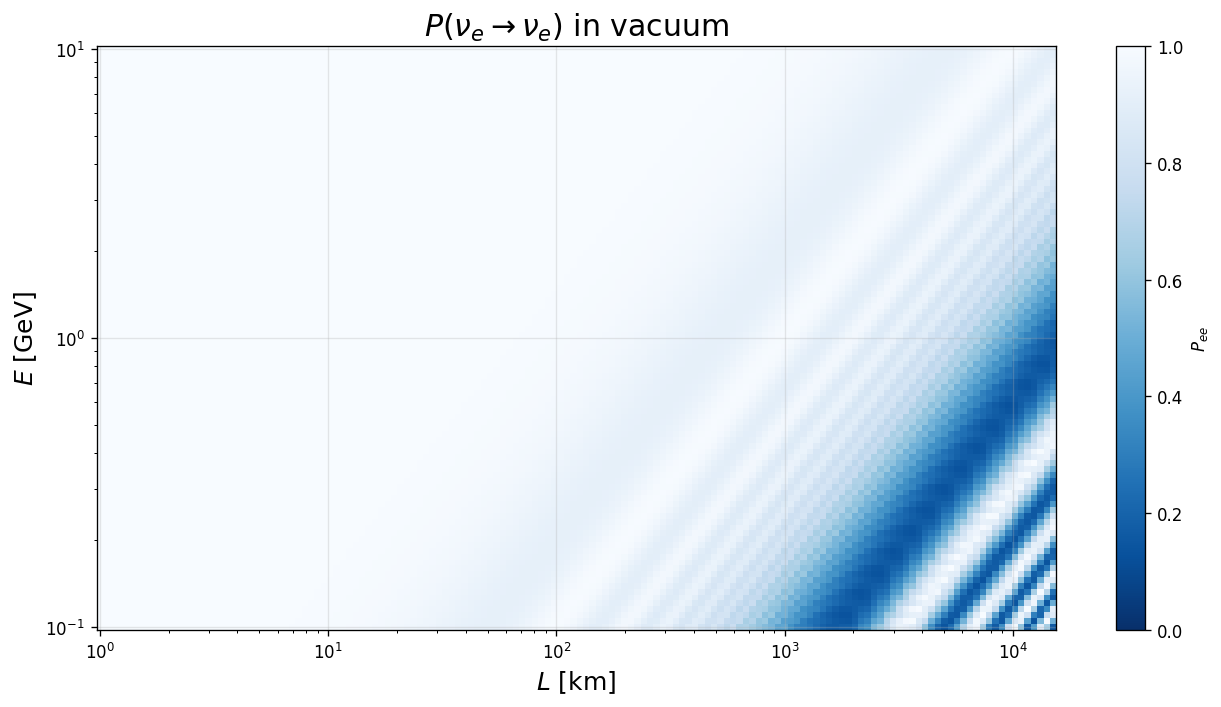

v:\output\analysis\vacuum\vf1_fig61_1_pee_2d_map.png


In [13]:
NE, NL = 100, 150
E_2d = torch.logspace(math.log10(100.0), math.log10(1e4), NE,
                       dtype=ctx.dtype, device=ctx.device)  # MeV
L_2d = torch.logspace(math.log10(1.0),   math.log10(15000.0), NL,
                       dtype=ctx.dtype, device=ctx.device)  # km

# Vectorised 2-D computation: (NE, 1) × (1, NL) → (NE, NL, 3, 3)
P_2d = vacuum_probability_transition(osc, E_2d[:, None], L_2d[None, :])  # (NE, NL, 3, 3)
P_ee_2d = to_numpy(P_2d[:, :, 0, 0])   # shape (NE, NL)

E_np_2d = to_numpy(E_2d) * 1e-3   # GeV
L_np_2d = to_numpy(L_2d)

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(L_np_2d, E_np_2d, P_ee_2d, cmap="Blues_r", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label=r"$P_{ee}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$L$ [km]", fontsize=15)
ax.set_ylabel(r"$E$ [GeV]", fontsize=15)
ax.set_title(r"$P(\nu_e \to \nu_e)$ in vacuum", fontsize=18)
fig.tight_layout()
save_and_show("vf1_fig61_1_pee_2d_map.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.2 $P_{\mu e}(E, L)$ Appearance Heatmap

$\nu_\mu\to\nu_e$ appearance probability on the same log-log grid. This channel is the primary
signal for long-baseline CP-violation searches.

**Expected results:** 
- $P_{\mu e}$ peaks at order
$\sin^2(2\theta_{13})\sin^2(\theta_{23})\sin^2(\Delta m^2_{31} L/4E)\approx0.05$ near
$L_{\rm osc}/2$ at each energy.






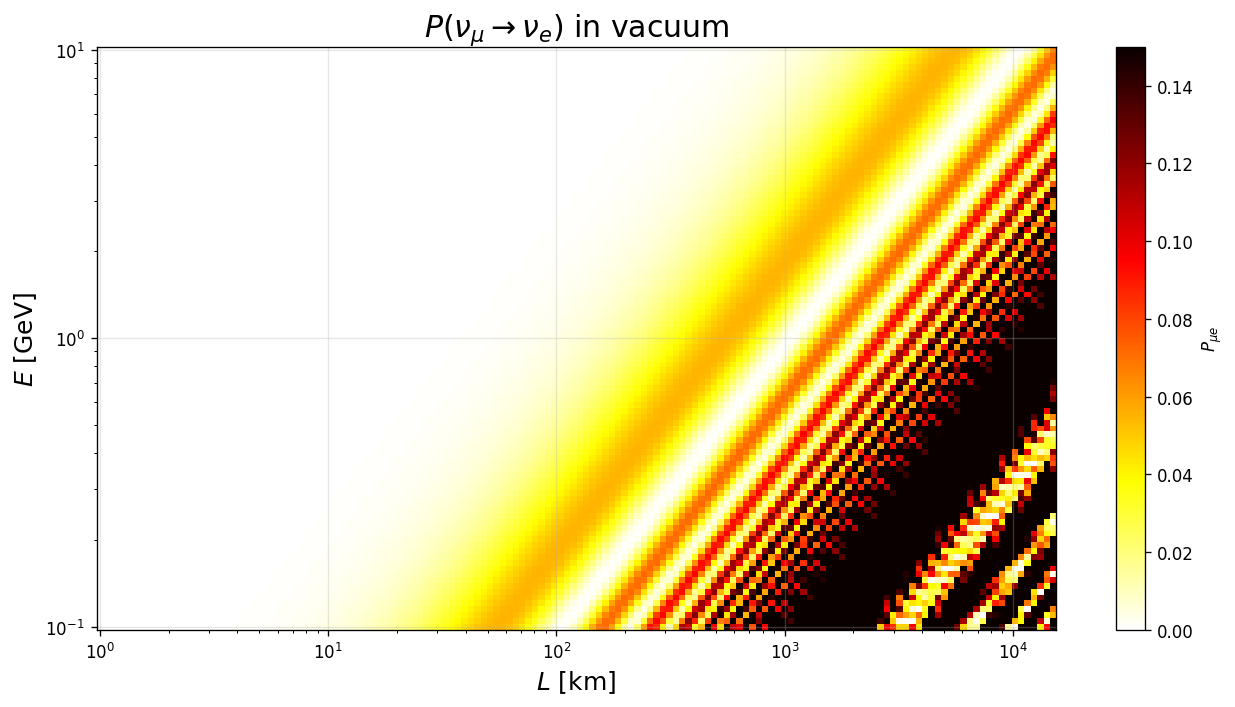

v:\output\analysis\vacuum\vf1_fig62_1_pemu_2d_map.png


In [14]:
P_mue_2d = to_numpy(P_2d[:, :, 0, 1])  # P[beta=e, alpha=mu], shape (NE, NL)

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(L_np_2d, E_np_2d, P_mue_2d, cmap="hot_r", vmin=0, vmax=0.15,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu e}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$L$ [km]", fontsize=15)
ax.set_ylabel(r"$E$ [GeV]", fontsize=15)
ax.set_title(r"$P(\nu_\mu \to \nu_e)$ in vacuum", fontsize=18)
fig.tight_layout()
save_and_show("vf1_fig62_1_pemu_2d_map.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Summary
---
This notebook documented **Vacuum Neutrino Analysis 1 - Oscillation Probabilities**, including its methodology, principal calculations and resulting diagnostics.






**Global consistency diagnostics**

| Quantity | Value |
|---|---|
| $L_{\rm osc}(\Delta m^2_{21})$ at 1 GeV | ≈ 33 500 km |
| $L_{\rm osc}(\Delta m^2_{31})$ at 1 GeV | ≈ 987 km |
| $P_{ee}$ at (1 GeV, 500 km) | ≈ 0.91 (near first survival minimum) |
| $P_{\mu e}$ maximum near $E\approx1\,\mathrm{GeV}$ | ≈ 0.05 |
| Unitarity violation | < 1e-13 (machine precision) |

**Physical interpretation:**
- Vacuum neutrino oscillations are fully governed by the PMNS mixing angles and the two
  independent mass-squared splittings $\Delta m^2_{21}$ (solar) and $\Delta m^2_{31}$
  (atmospheric).
- At sub-GeV-to-few-GeV energies and few-hundred-to-~1500 km baselines, the dominant
  oscillation scale is $\Delta m^2_{31}$, with $\Delta m^2_{21}$ providing a slow modulation
  that becomes important only at very long baselines or very low energies.
- The $\nu_\mu\to\nu_e$ appearance probability carries the imprint of the CP phase
  $\delta_{\rm CP}$, making it the primary discovery channel for CP violation in the lepton
  sector.
- Both row and column sums of the probability matrix are exactly 1 (unitarity) at all tested
  energies and baselines, confirming the correctness of the `vacuum_probability_transition`
  implementation.
